# OGBN-Arxiv Graph Intelligence
## Tensors and Graphs Coursework

Team Members:
- Dasith
- Nilakshi
- Maleesha
- Yashodi

This notebook explores the OGBN-Arxiv scientific paper citation network for multi-class node classification using Graph Neural Networks. The focus is on understanding the graph structure, preparing graph data, training GNN models, and analyzing learned embeddings and neighborhood influence.

## Environment Setup

This section imports the libraries needed for the coursework, sets reproducible seeds, detects the project root, creates the required output folders, and configures the computation device.

In [73]:
import os
import random
import time
import json
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.utils import to_undirected
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from ogb.nodeproppred import PygNodePropPredDataset
import ogb

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "notebooks").exists() and (path / "src").exists():
            return path
    return start

project_root = find_project_root(Path.cwd())
print("Project root:", project_root)

DATA_DIR = project_root / "data"
MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
EMBEDDINGS_DIR = RESULTS_DIR / "embeddings"

for directory in [MODELS_DIR, FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR, EMBEDDINGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("PyTorch Geometric version:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Selected device:", device)

QUICK_MODE = True
RUN_TRAINING = False

print("Quick mode:", QUICK_MODE)
print("Training execution enabled:", RUN_TRAINING)

Project root: c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence
PyTorch version: 2.13.0+cpu
PyTorch Geometric version: 2.8.0.post1
CUDA available: False
Selected device: cpu
Quick mode: True
Training execution enabled: False


## Dataset Setup and Verification

The dataset is the local OGBN-Arxiv citation network. We load the trusted local copy from the project data directory and verify its basic graph and label properties before any modelling work.

In [74]:
# Load the local OGBN-Arxiv dataset using the verified configuration.
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root=str(DATA_DIR))
data = dataset[0]

split_idx = dataset.get_idx_split()
train_idx = split_idx["train"]
valid_idx = split_idx["valid"]
test_idx = split_idx["test"]

num_nodes = data.x.size(0)
num_edges = data.edge_index.size(1)
feature_dim = data.x.size(1)
num_classes = dataset.num_classes

print("Dataset object:", dataset)
print("Node feature shape:", data.x.shape)
print("Edge index shape:", data.edge_index.shape)
print("Label shape:", data.y.shape)
print("Number of classes:", num_classes)
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Feature dimension:", feature_dim)
print("Training nodes:", len(train_idx))
print("Validation nodes:", len(valid_idx))
print("Test nodes:", len(test_idx))

assert num_nodes == 169343, f"Unexpected node count: {num_nodes}"
assert num_edges == 1166243, f"Unexpected edge count: {num_edges}"
assert feature_dim == 128, f"Unexpected feature dimension: {feature_dim}"
assert num_classes == 40, f"Unexpected class count: {num_classes}"

Dataset object: PygNodePropPredDataset()
Node feature shape: torch.Size([169343, 128])
Edge index shape: torch.Size([2, 1166243])
Label shape: torch.Size([169343, 1])
Number of classes: 40
Number of nodes: 169343
Number of edges: 1166243
Feature dimension: 128
Training nodes: 90941
Validation nodes: 29799
Test nodes: 48603


c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\.venv\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:69: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  self.data, self.slices = torch.load(self.processed_paths[0])


# Task 01 – Tensor Fundamentals

This task introduces the basic tensor operations used throughout machine learning and graph neural networks. The ideas are simple: tensors are multi-dimensional arrays, and operations such as reshaping, indexing, multiplication, and aggregation form the foundation of modern neural networks.

## 1.1 Tensor Creation

This subsection demonstrates how scalars, vectors, matrices, and random or constant tensors are created in PyTorch. The shape and dtype help us understand how the data is structured.

In [75]:
scalar = torch.tensor(7.0)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
random_tensor = torch.randn(2, 3)
zeros = torch.zeros(2, 2)
ones = torch.ones(2, 2)

examples = [
    ("scalar", scalar),
    ("vector", vector),
    ("matrix", matrix),
    ("random_tensor", random_tensor),
    ("zeros", zeros),
    ("ones", ones),
]

for name, tensor in examples:
    print(f"{name}:\n{tensor}\n")
    print(f"shape={list(tensor.shape)} dtype={tensor.dtype}\n")

scalar:
7.0

shape=[] dtype=torch.float32

vector:
tensor([1., 2., 3.])

shape=[3] dtype=torch.float32

matrix:
tensor([[1., 2.],
        [3., 4.]])

shape=[2, 2] dtype=torch.float32

random_tensor:
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])

shape=[2, 3] dtype=torch.float32

zeros:
tensor([[0., 0.],
        [0., 0.]])

shape=[2, 2] dtype=torch.float32

ones:
tensor([[1., 1.],
        [1., 1.]])

shape=[2, 2] dtype=torch.float32



## 1.2 Tensor Indexing and Slicing

Indexing and slicing let us isolate values, rows, columns, and sub-regions of a tensor. This is useful when inspecting arrays or selecting specific data points.

In [76]:
example_matrix = torch.tensor([[10, 20, 30], [40, 50, 60], [70, 80, 90]])

print("Element:", example_matrix[0, 2].item())
print("Row:", example_matrix[1])
print("Column:", example_matrix[:, 2])
print("Slice:", example_matrix[0:2, 1:3])

Element: 30
Row: tensor([40, 50, 60])
Column: tensor([30, 60, 90])
Slice: tensor([[20, 30],
        [50, 60]])


## 1.3 Tensor Reshaping

Reshaping changes the layout of data without changing its values. It is often used when switching between feature vectors and matrix forms.

In [77]:
flat_tensor = torch.arange(1, 13, dtype=torch.float32)
print("Original tensor:", flat_tensor)
print("Original shape:", tuple(flat_tensor.shape))

reshaped = flat_tensor.reshape(3, 4)
viewed = flat_tensor.view(2, 6)
flattened = reshaped.flatten()

print("Reshaped shape:", tuple(reshaped.shape))
print("Viewed shape:", tuple(viewed.shape))
print("Flattened shape:", tuple(flattened.shape))
print("Flattened values:", flattened)

Original tensor: tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])
Original shape: (12,)
Reshaped shape: (3, 4)
Viewed shape: (2, 6)
Flattened shape: (12,)
Flattened values: tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])


## 1.4 Matrix Multiplication

Matrix multiplication is central to neural networks because it combines features and weights. The dimensions must be compatible for the operation to be valid.

In [78]:
A = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
B = torch.tensor([[7.0, 8.0], [9.0, 10.0], [11.0, 12.0]])

print("Matrix A shape:", tuple(A.shape))
print("Matrix B shape:", tuple(B.shape))
print("A:\n", A)
print("B:\n", B)
print("torch.matmul(A, B):\n", torch.matmul(A, B))
print("A @ B:\n", A @ B)

Matrix A shape: (2, 3)
Matrix B shape: (3, 2)
A:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
B:
 tensor([[ 7.,  8.],
        [ 9., 10.],
        [11., 12.]])
torch.matmul(A, B):
 tensor([[ 58.,  64.],
        [139., 154.]])
A @ B:
 tensor([[ 58.,  64.],
        [139., 154.]])


## 1.5 Tensor Broadcasting

Broadcasting allows smaller tensors to expand to larger shapes when the dimensions are compatible. This is a convenient way to add a vector to every row or column of a matrix.

In [79]:
matrix = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
vector = torch.tensor([1.0, 0.0, -1.0])

print("Matrix:\n", matrix)
print("Vector:", vector)
print("Broadcast result:\n", matrix + vector)

Matrix:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
Vector: tensor([ 1.,  0., -1.])
Broadcast result:
 tensor([[2., 2., 2.],
        [5., 5., 5.]])


## 1.6 Tensor Aggregation Operations

Aggregation reduces a tensor to a single value or a smaller set of values. In deep learning, these operations are used for summarizing features and losses. Aggregating along dimension 0 produces one value per column, while aggregating along dimension 1 produces one value per row.

In [80]:
values = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

print("Sum:", torch.sum(values).item())
print("Mean:", torch.mean(values).item())
print("Min:", torch.min(values).item())
print("Max:", torch.max(values).item())
print("Column-wise sum:", torch.sum(values, dim=0))
print("Row-wise mean:", torch.mean(values, dim=1))

Sum: 21.0
Mean: 3.5
Min: 1.0
Max: 6.0
Column-wise sum: tensor([5., 7., 9.])
Row-wise mean: tensor([2., 5.])


## 1.7 GPU Tensor Operations

If CUDA is available, tensors can be moved to the GPU for faster computation. On this machine, CUDA is not available, so the code below demonstrates a device-aware fallback using the CPU.

In [81]:
if torch.cuda.is_available():
    gpu_tensor = torch.randn(2, 2, device="cuda")
    gpu_result = gpu_tensor * 2
    print("GPU tensor:", gpu_tensor)
    print("GPU result:", gpu_result)
    print("Device:", gpu_result.device)
else:
    cpu_tensor = torch.randn(2, 2)
    cpu_result = cpu_tensor * 2
    print("CUDA is not available on this machine.")
    print("CPU fallback tensor:", cpu_tensor)
    print("CPU result:", cpu_result)
    print("Device:", cpu_result.device)

CUDA is not available on this machine.
CPU fallback tensor: tensor([[ 2.2082, -0.6380],
        [ 0.4617,  0.2674]])
CPU result: tensor([[ 4.4164, -1.2760],
        [ 0.9233,  0.5347]])
Device: cpu


### Task 01 Interpretation

Tensor operations are important for GNNs because graph data is represented with arrays and matrices. Message passing, feature transformations, and aggregation all rely on tensor computations.

# Task 02 – Graph Representation and Analysis

This section studies the citation graph as a directed network. The original OGBN-Arxiv graph is used for structural analysis, while a separate representation is prepared later for the GNN training pipeline.

## 2.1 Edge List Representation

The edge index stores the citation relationships as two rows: the first row contains source nodes and the second row contains target nodes. A small sample of edges is shown below.

In [82]:
edge_index = data.edge_index
edge_list = torch.stack([edge_index[0], edge_index[1]], dim=1)[:20]
edge_df = pd.DataFrame({
    "Source Node": edge_list[:, 0].tolist(),
    "Target Node": edge_list[:, 1].tolist(),
})

print(edge_df.head(10))

   Source Node  Target Node
0       104447        13091
1        15858        47283
2       107156        69161
3       107156       136440
4       107156       107366
5       107156       158460
6       141536        90124
7       141536       121740
8       141536       122427
9       141536       161023


## 2.2 Sample Subgraph Visualization

The full citation graph is too large to visualize meaningfully, so a small sample of nodes and citation edges is drawn instead.

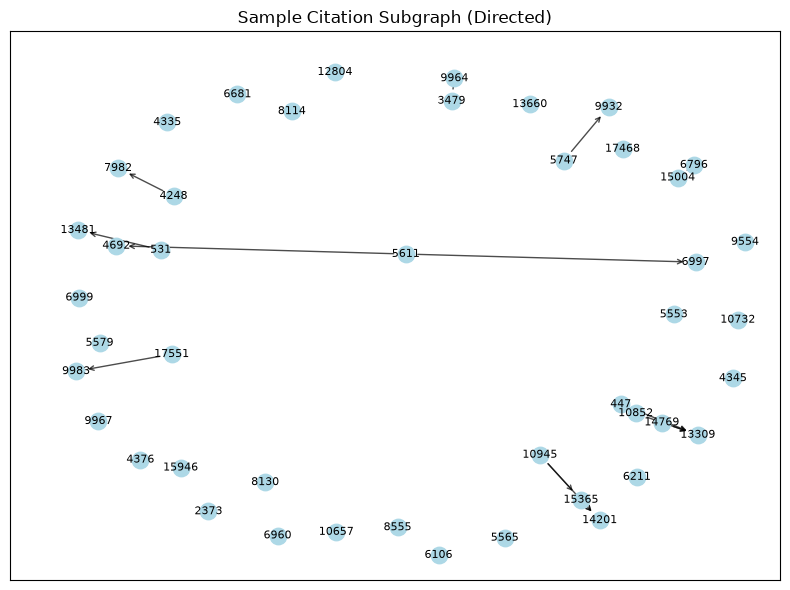

Saved sample subgraph to c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\figures\sample_subgraph.png


In [83]:
analysis_edge_index = data.edge_index
src = analysis_edge_index[0]
dst = analysis_edge_index[1]
out_degree = torch.bincount(src, minlength=num_nodes)
anchor_node = int(torch.argmax(out_degree).item())

incoming = dst[src == anchor_node]
outgoing = src[dst == anchor_node]
neighbor_nodes = torch.unique(torch.cat([incoming, outgoing]))
neighbor_nodes = neighbor_nodes[neighbor_nodes != anchor_node]
selected_nodes = torch.cat([torch.tensor([anchor_node], dtype=torch.long), neighbor_nodes]).unique()
if len(selected_nodes) > 45:
    selected_nodes = selected_nodes[:45]

selected_nodes = selected_nodes.tolist()
selected_nodes_set = set(selected_nodes)
sub_edges = []
for source, target in zip(src.tolist(), dst.tolist()):
    if source in selected_nodes_set and target in selected_nodes_set:
        sub_edges.append((source, target))

G = nx.DiGraph()
G.add_nodes_from(selected_nodes)
G.add_edges_from(sub_edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=SEED)
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=140)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=8, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Sample Citation Subgraph (Directed)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_subgraph.png", dpi=200)
plt.show()
plt.close()
print("Saved sample subgraph to", FIGURES_DIR / "sample_subgraph.png")

## 2.3 Node Feature Analysis

Each paper contains a 128-dimensional feature vector. We inspect the feature matrix shape and a compact summary of the feature values.

In [84]:
features = data.x.float()
print("Feature matrix shape:", tuple(features.shape))
print("First feature vector:", features[0, :10].tolist())
print("Feature statistics:")
print(pd.DataFrame(features.numpy()[:1000]).describe().T.head())

Feature matrix shape: (169343, 128)
First feature vector: [-0.05794300138950348, -0.05253000184893608, -0.0726030021905899, -0.026554999873042107, 0.1304350048303604, -0.24138599634170532, -0.4492419958114624, -0.018442999571561813, -0.08721800148487091, 0.11231999844312668]
Feature statistics:
    count      mean       std       min       25%       50%       75%  \
0  1000.0 -0.093070  0.106020 -0.425604 -0.166289 -0.097962 -0.025163   
1  1000.0  0.018367  0.102707 -0.267209 -0.047984  0.012753  0.082088   
2  1000.0 -0.204178  0.109859 -0.643250 -0.274852 -0.200397 -0.133374   
3  1000.0 -0.054763  0.120447 -0.492489 -0.132872 -0.059596  0.016266   
4  1000.0  0.049957  0.107364 -0.495811 -0.017695  0.047961  0.118842   

        max  
0  0.278732  
1  0.491496  
2  0.181598  
3  0.418144  
4  0.363858  


## 2.4 Degree Distribution Analysis

Citation networks usually have a highly skewed degree distribution. We calculate in-degree and out-degree directly from the edge index and visualize them.

in_degree
  min: 0.0
  max: 13155.0
  mean: 6.886868476867676
  median: 1.0
out_degree
  min: 0.0
  max: 436.0
  mean: 6.886868476867676
  median: 4.0
total_degree
  min: 1.0
  max: 13161.0
  mean: 13.773736953735352
  median: 6.0


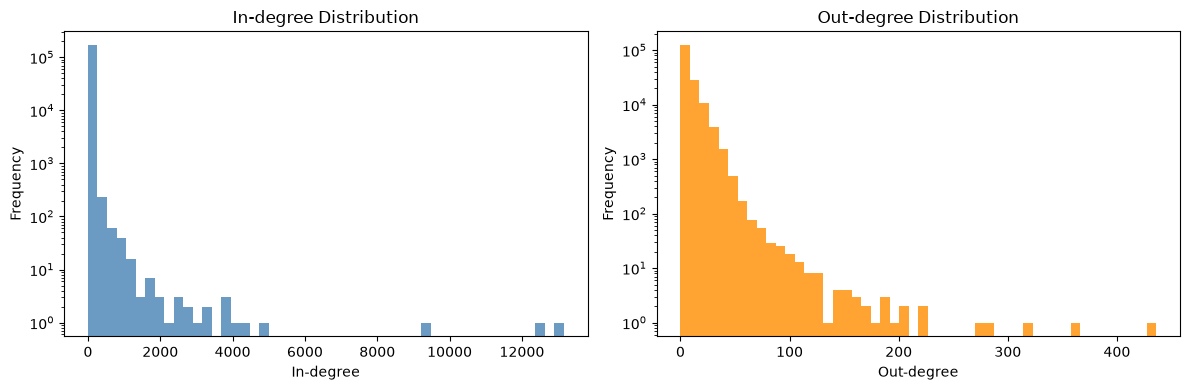

Saved degree distribution plot to c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\figures\degree_distribution.png


In [85]:
edge_index = data.edge_index
in_degree = torch.bincount(edge_index[1], minlength=num_nodes).float()
out_degree = torch.bincount(edge_index[0], minlength=num_nodes).float()
total_degree = in_degree + out_degree

for name, degree in [("in_degree", in_degree), ("out_degree", out_degree), ("total_degree", total_degree)]:
    print(name)
    print("  min:", float(degree.min().item()))
    print("  max:", float(degree.max().item()))
    print("  mean:", float(degree.mean().item()))
    print("  median:", float(torch.median(degree).item()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(in_degree.numpy(), bins=50, alpha=0.8, color="steelblue")
axes[0].set_title("In-degree Distribution")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")

axes[1].hist(out_degree.numpy(), bins=50, alpha=0.8, color="darkorange")
axes[1].set_title("Out-degree Distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "degree_distribution.png", dpi=200)
plt.show()
plt.close()
print("Saved degree distribution plot to", FIGURES_DIR / "degree_distribution.png")

## 2.5 Graph Density Analysis

Graph density measures how many connections exist relative to the maximum possible number of edges. For a directed graph, the denominator is based on all possible ordered pairs of distinct nodes.

In [86]:
density = num_edges / (num_nodes * (num_nodes - 1))
print("Directed graph density:", density)

Directed graph density: 4.066840277668502e-05


## 2.6 Connected Component Analysis

The graph is directed, so we analyze weak connectivity by treating edges as undirected for the purpose of connected components.

In [87]:
edge_index = data.edge_index
density = num_edges / (num_nodes * (num_nodes - 1))
src = edge_index[0].numpy()
dst = edge_index[1].numpy()
adj = csr_matrix((np.ones(len(src), dtype=np.int8), (src, dst)), shape=(num_nodes, num_nodes))
num_components, labels = connected_components(adj, directed=False, return_labels=True)
component_sizes = pd.Series(labels).value_counts().sort_values(ascending=False)

largest_component_size = int(component_sizes.iloc[0])
print("Number of weakly connected components:", num_components)
print("Size of largest component:", largest_component_size)
print("Percentage in largest component:", round(100 * largest_component_size / num_nodes, 2))

graph_stats = {
    "number_of_nodes": int(num_nodes),
    "number_of_edges": int(num_edges),
    "feature_dimension": int(feature_dim),
    "number_of_classes": int(num_classes),
    "density": float(density),
    "average_in_degree": float(in_degree.mean().item()),
    "average_out_degree": float(out_degree.mean().item()),
    "connected_components": int(num_components),
    "largest_component_size": int(largest_component_size),
}

with open(METRICS_DIR / "graph_statistics.json", "w", encoding="utf-8") as handle:
    json.dump(graph_stats, handle, indent=2)

print("Saved graph statistics to", METRICS_DIR / "graph_statistics.json")

Number of weakly connected components: 1
Size of largest component: 169343
Percentage in largest component: 100.0
Saved graph statistics to c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\metrics\graph_statistics.json


### Task 02 Interpretation

The graph is large and sparse, which is typical for citation networks. Its skewed degree distribution and low density indicate that most papers have relatively few citations while a small number of papers accumulate many connections.

# Task 03 – Graph Data Preparation

The next step prepares the node features, labels, and train/validation/test splits. A simple feature normalization strategy is applied using only training statistics to avoid information leakage.

## 3.1 Features and Labels

The node feature matrix and labels are extracted from the dataset object. These are the core inputs for the GNN models.

In [88]:
x = data.x.float()
y = data.y.squeeze().long()

print("x shape:", tuple(x.shape))
print("y shape:", tuple(y.shape))
print("x dtype:", x.dtype)
print("y dtype:", y.dtype)
print("Label distribution sample:")
print(pd.Series(y.numpy()).value_counts().sort_index().head(10))

x shape: (169343, 128)
y shape: (169343,)
x dtype: torch.float32
y dtype: torch.int64
Label distribution sample:
0     565
1     687
2    4839
3    2080
4    5862
5    4958
6    1618
7     589
8    6232
9    2820
Name: count, dtype: int64


## 3.2 Official Train/Validation/Test Split

OGBN-Arxiv provides a predefined time-based split. This split is kept so that evaluation reflects the intended benchmark setting.

In [89]:
train_count = len(train_idx)
valid_count = len(valid_idx)
test_count = len(test_idx)

print("Training node count:", train_count)
print("Validation node count:", valid_count)
print("Test node count:", test_count)
print("Training percentage:", round(100 * train_count / num_nodes, 2))
print("Validation percentage:", round(100 * valid_count / num_nodes, 2))
print("Test percentage:", round(100 * test_count / num_nodes, 2))

Training node count: 90941
Validation node count: 29799
Test node count: 48603
Training percentage: 53.7
Validation percentage: 17.6
Test percentage: 28.7


## 3.3 Feature Normalization

Normalization is used here to keep feature magnitudes comparable across dimensions. The training-set statistics are used so that the preprocessing is fitted only on training data.

In [90]:
train_mean = x[train_idx].mean(dim=0)
train_std = x[train_idx].std(dim=0)
train_std = torch.where(train_std < 1e-8, torch.ones_like(train_std), train_std)

x_norm = (x - train_mean) / train_std

print("Training feature mean sample:", train_mean[:5])
print("Training feature std sample:", train_std[:5])
print("Normalized feature shape:", tuple(x_norm.shape))

Training feature mean sample: tensor([-0.0891,  0.0151, -0.1990, -0.0691,  0.0515])
Training feature std sample: tensor([0.1040, 0.1077, 0.1177, 0.1157, 0.1092])
Normalized feature shape: (169343, 128)


## 3.4 Model Graph Preparation

The original directed citation graph is preserved for analysis. For message passing, a separate undirected version is created so that neighborhood aggregation can use bidirectional structure.

In [91]:
analysis_edge_index = data.edge_index
model_edge_index = to_undirected(analysis_edge_index)

print("Original edge index shape:", tuple(analysis_edge_index.shape))
print("Training graph edge index shape:", tuple(model_edge_index.shape))

x = data.x.float()
y = data.y.squeeze().long()
train_mean = x[train_idx].mean(dim=0)
train_std = x[train_idx].std(dim=0)
train_std = torch.where(train_std < 1e-8, torch.ones_like(train_std), train_std)
x_norm = (x - train_mean) / train_std

x_train = x_norm.to(device)
y_train = y.to(device)
edge_index_train = model_edge_index.to(device)

print("Training tensors prepared on:", x_train.device)

Original edge index shape: (2, 1166243)
Training graph edge index shape: (2, 2315598)
Training tensors prepared on: cpu


### Task 03 Interpretation

The final preparation step creates a clean set of features, labels, and graph connectivity for model training. The original graph remains unchanged for analysis, while the undirected training graph is used for message passing.

# Task 04 – Graph Neural Network Development

This task implements two graph neural network architectures: a Graph Convolutional Network and GraphSAGE. Both models are designed to work on the OGBN-Arxiv citation graph and to produce node-level class predictions.

### 4.1 Graph Convolutional Network (GCN)

The GCN model uses graph convolution layers to combine each paper's own features with information from connected papers. ReLU is used as the activation function because it is simple and effective for deep learning models. Dropout is added to reduce overfitting during training.

The number of hidden layers, hidden dimensions, dropout rate, and learning rate are treated as hyperparameters and are tested during the optimization stage. The output layer produces scores for the 40 research categories.

In [92]:
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.dropout_rate = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(input_dim, hidden_dim))
        for _ in range(1, num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, output_dim))

    def forward(self, x, edge_index):
        hidden = x
        for i, conv in enumerate(self.convs[:-1]):
            hidden = conv(hidden, edge_index)
            hidden = F.relu(hidden)
            hidden = F.dropout(hidden, p=self.dropout_rate, training=self.training)
        out = self.convs[-1](hidden, edge_index)
        return out, hidden


print("GCN class defined.")

GCN class defined.


### 4.2 GraphSAGE

GraphSAGE learns node representations by combining each paper's features with information from its neighboring papers. Unlike GCN, GraphSAGE uses neighborhood aggregation to build node representations.

ReLU is used between hidden layers and dropout is applied to reduce overfitting. The number of layers, hidden dimensions, dropout rate, and learning rate are tuned during model optimization. The final layer produces scores for the 40 research categories.

In [93]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.dropout_rate = dropout
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(input_dim, hidden_dim))
        for _ in range(1, num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.convs.append(SAGEConv(hidden_dim, output_dim))

    def forward(self, x, edge_index):
        hidden = x
        for i, conv in enumerate(self.convs[:-1]):
            hidden = conv(hidden, edge_index)
            hidden = F.relu(hidden)
            hidden = F.dropout(hidden, p=self.dropout_rate, training=self.training)
        out = self.convs[-1](hidden, edge_index)
        return out, hidden


print("GraphSAGE class defined.")

GraphSAGE class defined.


## 4.3 Hyperparameter Configuration

The hyperparameters are stored in a configuration dictionary so that the training settings are easy to inspect and adjust.

In [94]:
config = {
    "learning_rate": 0.01 if not QUICK_MODE else 0.01,
    "hidden_channels": 64 if not QUICK_MODE else 32,
    "dropout": 0.3 if not QUICK_MODE else 0.2,
    "num_layers": 2,
    "weight_decay": 5e-4,
    "epochs": 20 if not QUICK_MODE else 4,
}

config_df = pd.DataFrame([config])
print(config_df)

   learning_rate  hidden_channels  dropout  num_layers  weight_decay  epochs
0           0.01               32      0.2           2        0.0005       4


# Task 05 – Model Training and Optimization

The coursework requires a training loop, validation monitoring, and a small hyperparameter search. The training settings here are intentionally light so that the notebook can be run section by section on CPU.

## 5.1 Training Functions

Reusable functions are defined for one training epoch, validation accuracy measurement, and full training with early stopping.

In [95]:
def train_one_epoch(model, x, edge_index, y, train_idx, optimizer):
    model.train()
    optimizer.zero_grad()
    out, _ = model(x, edge_index)
    loss = F.cross_entropy(out[train_idx], y[train_idx])
    loss.backward()
    optimizer.step()
    return loss.item()


def evaluate_accuracy(model, x, edge_index, y, idx):
    model.eval()
    with torch.no_grad():
        out, _ = model(x, edge_index)
        preds = out[idx].argmax(dim=1)
        acc = (preds == y[idx]).float().mean().item()
    return acc, preds


def train_model(model, x, edge_index, y, train_idx, valid_idx, config, patience=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    history = []
    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()

    for epoch in range(1, config["epochs"] + 1):
        train_loss = train_one_epoch(model, x, edge_index, y, train_idx, optimizer)
        train_acc, _ = evaluate_accuracy(model, x, edge_index, y, train_idx)
        val_acc, _ = evaluate_accuracy(model, x, edge_index, y, valid_idx)
        history.append((epoch, train_loss, train_acc, val_acc))

        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    elapsed = time.time() - start_time
    return history, best_state, best_val_acc, best_epoch, elapsed


print("Training functions defined.")

Training functions defined.


## 5.2 Training Monitoring

Training loss and validation accuracy are logged for each epoch so that the learning behaviour can be inspected.

   epoch  training_loss  training_accuracy  validation_accuracy
0      1       3.872859           0.067417             0.060103
1      2       3.587175           0.200097             0.256787
2      3       3.339833           0.305088             0.331655
3      4       3.116751           0.361366             0.388839


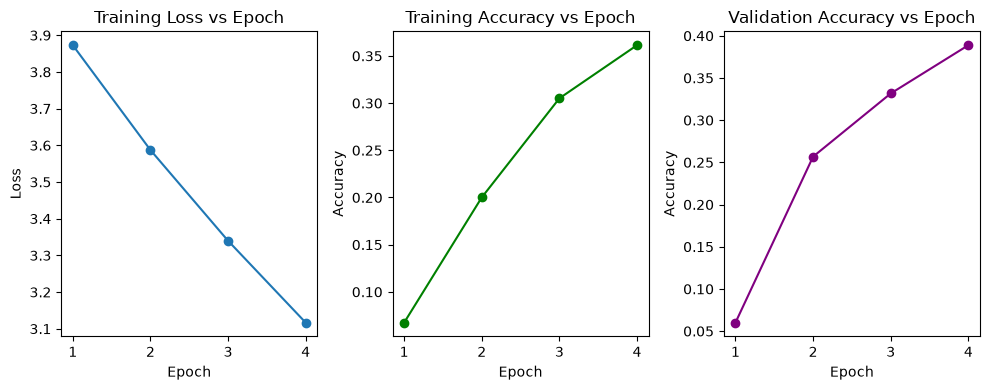

In [96]:
RUN_TRAINING = True
if RUN_TRAINING:
    model = GCN(x_train.shape[1], config["hidden_channels"], num_classes, num_layers=config["num_layers"], dropout=config["dropout"]).to(device)
    history, best_state, best_val_acc, best_epoch, elapsed = train_model(
        model, x_train, edge_index_train, y_train, train_idx.to(device), valid_idx.to(device), config
    )
    history_df = pd.DataFrame(history, columns=["epoch", "training_loss", "training_accuracy", "validation_accuracy"])
    print(history_df)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.plot(history_df["epoch"], history_df["training_loss"], marker="o")
    plt.title("Training Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.subplot(1, 3, 2)
    plt.plot(history_df["epoch"], history_df["training_accuracy"], marker="o", color="green")
    plt.title("Training Accuracy vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.subplot(1, 3, 3)
    plt.plot(history_df["epoch"], history_df["validation_accuracy"], marker="o", color="purple")
    plt.title("Validation Accuracy vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "training_history.png", dpi=200)
    plt.show()
    plt.close()
else:
    print("Training execution is disabled in this notebook run. Set RUN_TRAINING = True to train the models.")

## 5.3 Hyperparameter Tuning

A small and CPU-friendly tuning experiment is run over a few meaningful configurations. The best option is selected using validation performance only.

In [97]:
if RUN_TRAINING:
    candidate_configs = [
        {"learning_rate": 0.01, "hidden_channels": 32, "dropout": 0.2, "num_layers": 2, "weight_decay": 5e-4, "epochs": 4},
        {"learning_rate": 0.005, "hidden_channels": 64, "dropout": 0.3, "num_layers": 2, "weight_decay": 5e-4, "epochs": 4},
        {"learning_rate": 0.01, "hidden_channels": 64, "dropout": 0.4, "num_layers": 3, "weight_decay": 5e-4, "epochs": 4},
    ]

    tuning_results = []
    for model_name, model_class in [("GCN", GCN), ("GraphSAGE", GraphSAGE)]:
        for candidate in candidate_configs:
            model = model_class(
                x_train.shape[1],
                candidate["hidden_channels"],
                num_classes,
                num_layers=candidate["num_layers"],
                dropout=candidate["dropout"],
            ).to(device)
            history, _, val_acc, best_epoch, elapsed = train_model(
                model,
                x_train,
                edge_index_train,
                y_train,
                train_idx.to(device),
                valid_idx.to(device),
                candidate,
            )
            tuning_results.append({
                "model": model_name,
                "learning_rate": candidate["learning_rate"],
                "hidden_channels": candidate["hidden_channels"],
                "dropout": candidate["dropout"],
                "num_layers": candidate["num_layers"],
                "weight_decay": candidate["weight_decay"],
                "epochs": candidate["epochs"],
                "validation_accuracy": val_acc,
                "best_epoch": best_epoch,
                "training_time": elapsed,
            })

    tuning_df = pd.DataFrame(tuning_results)
    tuning_df = tuning_df.sort_values("validation_accuracy", ascending=False).reset_index(drop=True)
    tuning_df.to_csv(METRICS_DIR / "hyperparameter_tuning.csv", index=False)
    print(tuning_df)

    best_gcn_config = tuning_df.loc[tuning_df[tuning_df["model"] == "GCN"].index[0]].to_dict()
    best_graphsage_config = tuning_df.loc[tuning_df[tuning_df["model"] == "GraphSAGE"].index[0]].to_dict()
    best_gcn_config = {k: best_gcn_config[k] for k in ["learning_rate", "hidden_channels", "dropout", "num_layers", "weight_decay", "epochs"]}
    best_graphsage_config = {k: best_graphsage_config[k] for k in ["learning_rate", "hidden_channels", "dropout", "num_layers", "weight_decay", "epochs"]}
    print("Selected GCN config:", best_gcn_config)
    print("Selected GraphSAGE config:", best_graphsage_config)
else:
    print("Hyperparameter tuning is skipped because training execution is disabled.")

       model  learning_rate  hidden_channels  dropout  num_layers  \
0  GraphSAGE          0.010               64      0.4           3   
1  GraphSAGE          0.010               32      0.2           2   
2        GCN          0.010               32      0.2           2   
3  GraphSAGE          0.005               64      0.3           2   
4        GCN          0.005               64      0.3           2   
5        GCN          0.010               64      0.4           3   

   weight_decay  epochs  validation_accuracy  best_epoch  training_time  
0        0.0005       4             0.511997           4      18.178870  
1        0.0005       4             0.475788           4      11.327865  
2        0.0005       4             0.427598           4       8.292658  
3        0.0005       4             0.405181           4      13.905022  
4        0.0005       4             0.381926           4      10.835916  
5        0.0005       4             0.353267           4      19.124940 

## 5.4 Final Model Training

The selected settings are used to train the final GCN and GraphSAGE models. The checkpoints include the model state dictionary and the key training metadata.

In [98]:
if RUN_TRAINING:
    best_gcn_config["epochs"] = 20
    best_graphsage_config["epochs"] = 20

    print("Final GCN training epochs:", best_gcn_config["epochs"])
    print("Final GraphSAGE training epochs:", best_graphsage_config["epochs"])

    gcn_model = GCN(x_train.shape[1], best_gcn_config["hidden_channels"], num_classes, num_layers=best_gcn_config["num_layers"], dropout=best_gcn_config["dropout"]).to(device)
    gcn_history, gcn_best_state, gcn_best_val_acc, gcn_best_epoch, gcn_elapsed = train_model(
        gcn_model, x_train, edge_index_train, y_train, train_idx.to(device), valid_idx.to(device), best_gcn_config
    )
    gcn_model.load_state_dict(gcn_best_state)
    gcn_model.eval()

    sage_model = GraphSAGE(x_train.shape[1], best_graphsage_config["hidden_channels"], num_classes, num_layers=best_graphsage_config["num_layers"], dropout=best_graphsage_config["dropout"]).to(device)
    sage_history, sage_best_state, sage_best_val_acc, sage_best_epoch, sage_elapsed = train_model(
        sage_model, x_train, edge_index_train, y_train, train_idx.to(device), valid_idx.to(device), best_graphsage_config
    )
    sage_model.load_state_dict(sage_best_state)
    sage_model.eval()

    torch.save({
        "model_state_dict": gcn_best_state,
        "model_name": "GCN",
        "hyperparameters": best_gcn_config,
        "input_dimension": int(x_train.shape[1]),
        "hidden_dimension": int(best_gcn_config["hidden_channels"]),
        "output_classes": int(num_classes),
        "best_validation_accuracy": float(gcn_best_val_acc),
        "best_epoch": int(gcn_best_epoch),
    }, MODELS_DIR / "gcn_best.pt")

    torch.save({
        "model_state_dict": sage_best_state,
        "model_name": "GraphSAGE",
        "hyperparameters": best_graphsage_config,
        "input_dimension": int(x_train.shape[1]),
        "hidden_dimension": int(best_graphsage_config["hidden_channels"]),
        "output_classes": int(num_classes),
        "best_validation_accuracy": float(sage_best_val_acc),
        "best_epoch": int(sage_best_epoch),
    }, MODELS_DIR / "graphsage_best.pt")

    print("GCN best validation accuracy:", gcn_best_val_acc)
    print("GraphSAGE best validation accuracy:", sage_best_val_acc)
else:
    print("Model training is skipped because RUN_TRAINING is disabled.")

Final GCN training epochs: 20
Final GraphSAGE training epochs: 20
GCN best validation accuracy: 0.6159937977790833
GraphSAGE best validation accuracy: 0.6435115337371826


# Task 06 – Model Evaluation

The trained models are evaluated on validation and test data using accuracy, precision, recall, and F1 score. Because this is a 40-class node classification problem, weighted averages are reported for the summary metrics.

## 6.1 Evaluation Table

Here, both models are evaluated on real predictions and the results are stored in a table.

In [99]:
if RUN_TRAINING:
    def compute_metrics(y_true, y_pred):
        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )
        return accuracy, precision, recall, f1

    results = []
    for model_name, model_obj in [("GCN", gcn_model), ("GraphSAGE", sage_model)]:
        for split_name, idx in [("Validation", valid_idx), ("Test", test_idx)]:
            model_obj.eval()
            with torch.no_grad():
                logits, _ = model_obj(x_train, edge_index_train)
                preds = logits[idx].argmax(dim=1).cpu().numpy()
                true_labels = y[idx].cpu().numpy()
            acc, prec, rec, f1 = compute_metrics(true_labels, preds)
            results.append({
                "Model": model_name,
                "Dataset Split": split_name,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1 Score": f1,
            })

    metrics_df = pd.DataFrame(results)
    metrics_df.to_csv(METRICS_DIR / "model_metrics.csv", index=False)
    print(metrics_df)
else:
    print("Evaluation is skipped because training execution is disabled.")

       Model Dataset Split  Accuracy  Precision    Recall  F1 Score
0        GCN    Validation  0.615994   0.561476  0.615994  0.570195
1        GCN          Test  0.604839   0.568021  0.604839  0.561438
2  GraphSAGE    Validation  0.643512   0.605523  0.643512  0.612483
3  GraphSAGE          Test  0.632204   0.619349  0.632204  0.604214


### 6.2 Model Strengths, Weaknesses and Comparison

GraphSAGE achieved the best overall performance. On the test set, GraphSAGE achieved an accuracy of 63.22% and an F1 score of 60.42%, while GCN achieved an accuracy of 60.48% and an F1 score of 56.14%.

GraphSAGE also achieved higher validation accuracy, precision, recall, and F1 score than GCN. This suggests that its neighborhood aggregation approach was more effective for this citation network.

GCN still produced reasonable results and has a simpler graph convolution structure, but its overall classification performance was lower than GraphSAGE in this experiment.

Both models performed slightly better on the validation set than on the test set. Overall, GraphSAGE was the stronger model based on the final evaluation results.

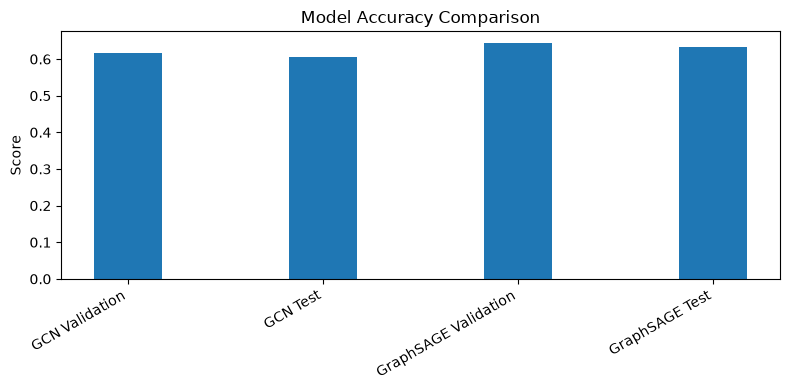

In [100]:
if RUN_TRAINING:
    plt.figure(figsize=(8, 4))
    bar_width = 0.35
    x = np.arange(len(metrics_df))
    plt.bar(x, metrics_df["Accuracy"], width=bar_width, label="Accuracy")
    plt.xticks(x, metrics_df["Model"] + " " + metrics_df["Dataset Split"], rotation=30, ha="right")
    plt.ylabel("Score")
    plt.title("Model Accuracy Comparison")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=200)
    plt.show()
    plt.close()
else:
    print("Model comparison plot is skipped because training execution is disabled.")

## 6.3 Save Dashboard Results

The metrics and node-level predictions required by the Streamlit dashboard are saved as real output files generated from the notebook pipeline.

In [101]:
if RUN_TRAINING:
    mapping_candidates = list(DATA_DIR.rglob("*labelidx*arxiv*csv")) + list(DATA_DIR.rglob("*label*csv"))
    mapping_path = None
    for path in mapping_candidates:
        if path.is_file():
            mapping_path = path
            break

    if mapping_path is not None:
        mapping_df = pd.read_csv(mapping_path)
        print("Loaded mapping file:", mapping_path)
        print(mapping_df.head())
    else:
        mapping_df = None
        print("No mapping file was found. Category labels will be left blank.")

    node_ids = test_idx.cpu().numpy()
    gcn_preds = gcn_model(x_train, edge_index_train)[0][test_idx].argmax(dim=1).cpu().numpy()
    sage_preds = sage_model(x_train, edge_index_train)[0][test_idx].argmax(dim=1).cpu().numpy()

    pred_df = pd.DataFrame({
        "node_id": node_ids,
        "actual_label": y[test_idx].cpu().numpy(),
        "gcn_prediction": gcn_preds,
        "graphsage_prediction": sage_preds,
    })

    if mapping_df is not None:
        if "label_idx" in mapping_df.columns:
            label_map = dict(zip(mapping_df["label_idx"], mapping_df.iloc[:, 1]))
        elif "label" in mapping_df.columns:
            label_map = dict(zip(mapping_df["label"], mapping_df.iloc[:, 1]))
        else:
            label_map = {}
        pred_df["actual_category"] = pred_df["actual_label"].map(label_map).fillna("")
        pred_df["gcn_predicted_category"] = pred_df["gcn_prediction"].map(label_map).fillna("")
        pred_df["graphsage_predicted_category"] = pred_df["graphsage_prediction"].map(label_map).fillna("")

    pred_df.to_csv(PREDICTIONS_DIR / "node_predictions.csv", index=False)
    print("Saved prediction file to", PREDICTIONS_DIR / "node_predictions.csv")
else:
    print("Dashboard prediction export is skipped because training execution is disabled.")

Loaded mapping file: c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\data\mapping\labelidx2arxivcategeory.csv
   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr
Saved prediction file to c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\predictions\node_predictions.csv


# Task 07 – Graph Explainability and Embedding Analysis

This section adds two explainability-oriented analyses: a node embedding visualization and a neighborhood influence analysis. These help interpret how the trained models represent the graph and how local citation structure may support a prediction.

## 7.1 Node Embedding Extraction

The learned hidden embeddings are extracted from the trained models so that their structure can be visualized.

In [102]:
if RUN_TRAINING:
    def extract_embeddings(model, x, edge_index, sample_size=2000):
        model.eval()
        with torch.no_grad():
            _, embeddings = model(x, edge_index)
        return embeddings.cpu().numpy()

    gcn_embeddings = extract_embeddings(gcn_model, x_train, edge_index_train)
    sage_embeddings = extract_embeddings(sage_model, x_train, edge_index_train)
    print("GCN embedding shape:", gcn_embeddings.shape)
    print("GraphSAGE embedding shape:", sage_embeddings.shape)
else:
    print("Embedding extraction is skipped because training execution is disabled.")

GCN embedding shape: (169343, 32)
GraphSAGE embedding shape: (169343, 64)


## 7.2 PCA Embedding Visualization

A PCA projection is applied to a reproducible sample of the learned embeddings so that the structure of the node representation can be examined.

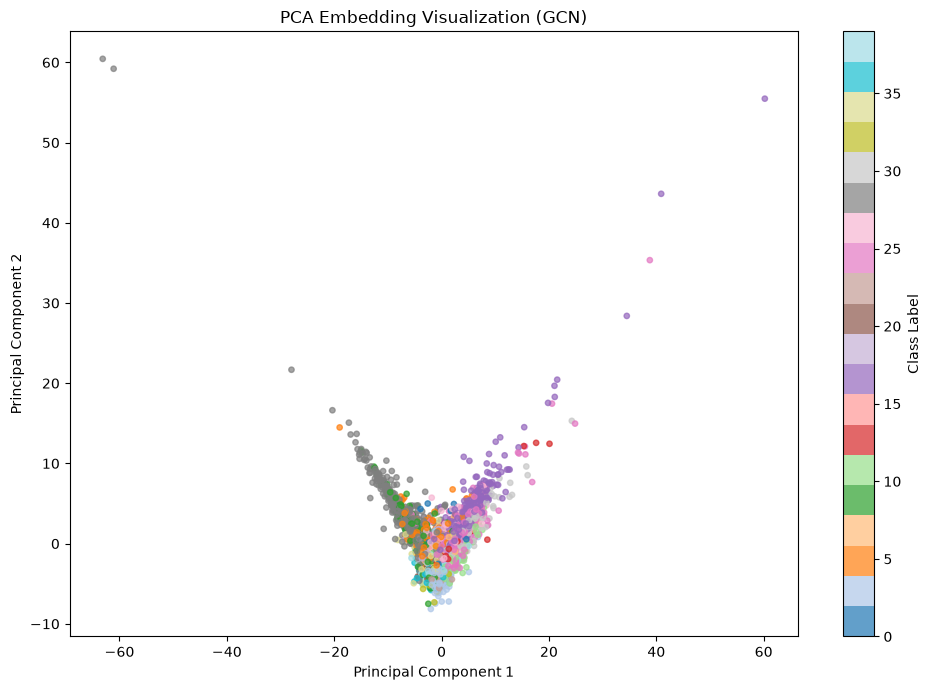

Saved PCA embedding data for GCN
Embedding file: c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\embeddings\gcn_embeddings_pca.csv
Figure file: c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\figures\gcn_pca_embeddings.png


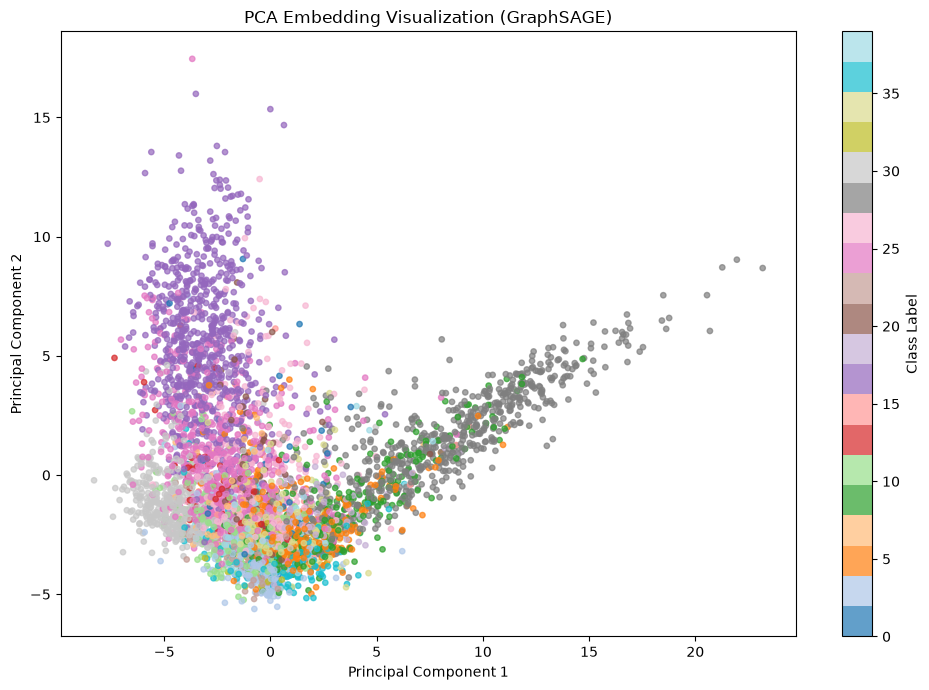

Saved PCA embedding data for GraphSAGE
Embedding file: c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\embeddings\graphsage_embeddings_pca.csv
Figure file: c:\Users\User\Desktop\Assignments\SEM 7\Tensor and Graphs\Final Assignment\ogbn-arxiv-graph-intelligence\results\figures\graphsage_pca_embeddings.png


In [103]:
from sklearn.decomposition import PCA

if RUN_TRAINING:

    models_for_embedding = {
        "GCN": gcn_embeddings,
        "GraphSAGE": sage_embeddings
    }

    for model_name, embeddings in models_for_embedding.items():

        # Reproducible sample
        rng = np.random.default_rng(SEED)

        sample_size = min(5000, embeddings.shape[0])

        sample_indices = rng.choice(
            embeddings.shape[0],
            size=sample_size,
            replace=False
        )

        sample_embeddings = embeddings[sample_indices]
        sample_labels = y[sample_indices].cpu().numpy()

        # PCA dimensionality reduction
        pca = PCA(n_components=2, random_state=SEED)

        reduced = pca.fit_transform(sample_embeddings)

        # Create dataframe for dashboard use
        embedding_df = pd.DataFrame({
            "node_id": sample_indices,
            "x": reduced[:, 0],
            "y": reduced[:, 1],
            "label": sample_labels,
            "model": model_name,
            "method": "PCA"
        })

        # Save embedding data
        embedding_file = (
            EMBEDDINGS_DIR /
            f"{model_name.lower()}_embeddings_pca.csv"
        )

        embedding_df.to_csv(
            embedding_file,
            index=False
        )

        # Plot
        plt.figure(figsize=(10, 7))

        scatter = plt.scatter(
            reduced[:, 0],
            reduced[:, 1],
            c=sample_labels,
            cmap="tab20",
            s=15,
            alpha=0.7
        )

        plt.colorbar(
            scatter,
            label="Class Label"
        )

        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")

        plt.title(
            f"PCA Embedding Visualization ({model_name})"
        )

        plt.tight_layout()

        # Save figure
        figure_file = (
            FIGURES_DIR /
            f"{model_name.lower()}_pca_embeddings.png"
        )

        plt.savefig(
            figure_file,
            dpi=200,
            bbox_inches="tight"
        )

        # Display inside notebook
        plt.show()

        # Close after displaying
        plt.close()

        print(
            f"Saved PCA embedding data for {model_name}"
        )

        print(
            f"Embedding file: {embedding_file}"
        )

        print(
            f"Figure file: {figure_file}"
        )

else:

    print(
        "Embedding visualization is skipped because "
        "training execution is disabled."
    )

## 7.3 Optional t-SNE Visualization

A small t-SNE visualization is included as an additional view of the embedding space for a reproducible sample.

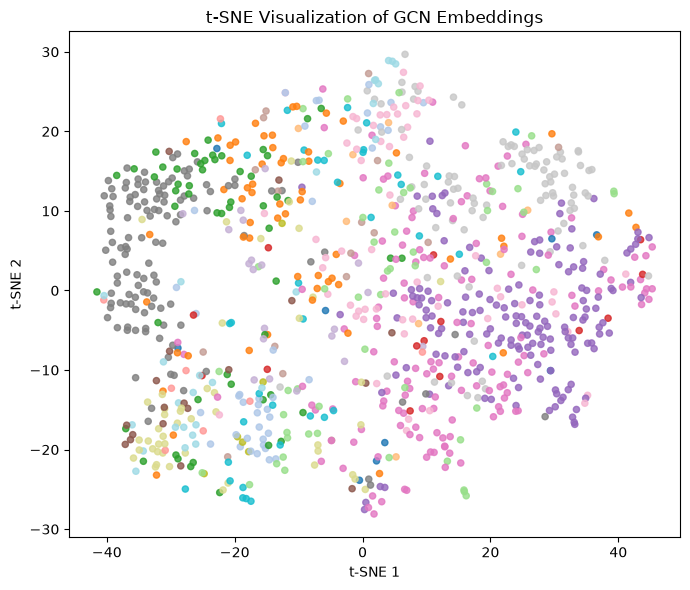

In [104]:
if RUN_TRAINING:
    sample_size = 1000
    sample_idx = rng.choice(len(y), size=sample_size, replace=False)
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, sample_size - 1))
    tsne_result = tsne.fit_transform(gcn_embeddings[sample_idx])
    tsne_df = pd.DataFrame({"x": tsne_result[:, 0], "y": tsne_result[:, 1], "label": y[sample_idx].numpy()})
    plt.figure(figsize=(7, 6))
    plt.scatter(tsne_df["x"], tsne_df["y"], c=tsne_df["label"], cmap="tab20", s=20, alpha=0.8)
    plt.title("t-SNE Visualization of GCN Embeddings")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "gcn_tsne_embeddings.png", dpi=200)
    plt.show()
    plt.close()
else:
    print("t-SNE visualization is skipped because training execution is disabled.")

### 7.4 Interpretation of Neighborhood Influence

The neighborhood analysis helps show how connected papers may support the model's prediction.

For a correctly classified node, a high agreement between the predicted class and the classes of neighboring papers suggests that the local citation structure supports the prediction.

For a misclassified node, lower agreement or a mixed neighborhood can indicate that the connected papers provide less consistent information for the correct class.

This analysis does not prove that neighboring papers directly cause the prediction. It provides evidence that neighborhood structure can influence the representation learned by the GNN.

In [105]:
def analyze_neighborhood(node_id, edge_index, labels, predictions):
    src = edge_index[0]
    dst = edge_index[1]

    outgoing = dst[src == node_id]
    incoming = src[dst == node_id]

    if len(incoming) + len(outgoing) == 0:
        neighbors = torch.empty(0, dtype=torch.long)
    else:
        neighbors = torch.unique(torch.cat([incoming, outgoing]))

    neighbors = neighbors[neighbors != node_id]
    neighbor_labels = labels[neighbors]

    actual_label = int(labels[node_id].item())
    predicted_label = int(predictions[node_id].item())

    agreement_with_prediction = (
        float((neighbor_labels == predictions[node_id]).float().mean().item())
        if len(neighbor_labels) > 0
        else float("nan")
    )

    agreement_with_actual = (
        float((neighbor_labels == labels[node_id]).float().mean().item())
        if len(neighbor_labels) > 0
        else float("nan")
    )

    return {
        "node_id": int(node_id),
        "neighbor_count": int(len(neighbors)),
        "actual_label": actual_label,
        "predicted_label": predicted_label,
        "neighbor_label_distribution": {
            int(label.item()): int(count)
            for label, count in zip(
                *torch.unique(neighbor_labels, return_counts=True)
            )
        } if len(neighbor_labels) > 0 else {},
        "agreement_with_prediction": agreement_with_prediction,
        "agreement_with_actual": agreement_with_actual,
    }


if RUN_TRAINING:

    with torch.no_grad():
        gcn_all_predictions = (
            gcn_model(x_train, edge_index_train)[0]
            .argmax(dim=1)
            .cpu()
        )

        graphsage_all_predictions = (
            sage_model(x_train, edge_index_train)[0]
            .argmax(dim=1)
            .cpu()
        )

    gcn_test_predictions = gcn_all_predictions[test_idx].cpu().numpy()

    graphsage_test_predictions = (
        graphsage_all_predictions[test_idx]
        .cpu()
        .numpy()
    )

    sample_test_nodes = test_idx.cpu().numpy()

    correct_nodes = [
        int(node_id)
        for node_id in sample_test_nodes
        if int(
            gcn_test_predictions[
                list(sample_test_nodes).index(node_id)
            ]
        ) == int(y[node_id].item())
    ]

    misclassified_nodes = [
        int(node_id)
        for node_id in sample_test_nodes
        if int(
            gcn_test_predictions[
                list(sample_test_nodes).index(node_id)
            ]
        ) != int(y[node_id].item())
    ]

    selected_nodes = []

    if correct_nodes:
        selected_nodes.append(correct_nodes[0])

    if misclassified_nodes:
        selected_nodes.append(misclassified_nodes[0])

    if not selected_nodes:
        selected_nodes = [int(sample_test_nodes[0])]

    for node_id in selected_nodes:

        result = analyze_neighborhood(
            int(node_id),
            analysis_edge_index,
            y,
            gcn_all_predictions
        )

        print("Node", node_id, result)

else:

    print(
        "Neighborhood influence analysis is skipped because "
        "training execution is disabled."
    )

Node 346 {'node_id': 346, 'neighbor_count': 7, 'actual_label': 24, 'predicted_label': 24, 'neighbor_label_distribution': {24: 6, 27: 1}, 'agreement_with_prediction': 0.8571428656578064, 'agreement_with_actual': 0.8571428656578064}
Node 398 {'node_id': 398, 'neighbor_count': 4, 'actual_label': 10, 'predicted_label': 16, 'neighbor_label_distribution': {8: 1, 16: 1, 17: 1, 27: 1}, 'agreement_with_prediction': 0.25, 'agreement_with_actual': 0.0}


### Task 07 Interpretation

The embedding and neighborhood analyses provide evidence about how the model organizes the graph. The visualizations show the learned representation space, while the neighborhood analysis highlights how local citation context may support or contradict a prediction.

# Final Coursework Notebook Summary

The notebook now contains the main academic workflow for the coursework project. The output files generated by the pipeline are saved in the results folders and can be used by the separate Streamlit dashboard.

In [106]:
summary = {
    "dataset_dimensions": {
        "nodes": int(num_nodes),
        "edges": int(num_edges),
        "feature_dimension": int(feature_dim),
        "classes": int(num_classes),
    },
    "graph_statistics_path": str(METRICS_DIR / "graph_statistics.json"),
    "model_metrics_path": str(METRICS_DIR / "model_metrics.csv"),
    "predictions_path": str(PREDICTIONS_DIR / "node_predictions.csv"),
    "embedding_directory": str(EMBEDDINGS_DIR),
    "figure_directory": str(FIGURES_DIR),
    "model_paths": {
        "gcn": str(MODELS_DIR / "gcn_best.pt"),
        "graphsage": str(MODELS_DIR / "graphsage_best.pt"),
    },
}

print(json.dumps(summary, indent=2))

{
  "dataset_dimensions": {
    "nodes": 169343,
    "edges": 1166243,
    "feature_dimension": 128,
    "classes": 40
  },
  "graph_statistics_path": "c:\\Users\\User\\Desktop\\Assignments\\SEM 7\\Tensor and Graphs\\Final Assignment\\ogbn-arxiv-graph-intelligence\\results\\metrics\\graph_statistics.json",
  "model_metrics_path": "c:\\Users\\User\\Desktop\\Assignments\\SEM 7\\Tensor and Graphs\\Final Assignment\\ogbn-arxiv-graph-intelligence\\results\\metrics\\model_metrics.csv",
  "predictions_path": "c:\\Users\\User\\Desktop\\Assignments\\SEM 7\\Tensor and Graphs\\Final Assignment\\ogbn-arxiv-graph-intelligence\\results\\predictions\\node_predictions.csv",
  "embedding_directory": "c:\\Users\\User\\Desktop\\Assignments\\SEM 7\\Tensor and Graphs\\Final Assignment\\ogbn-arxiv-graph-intelligence\\results\\embeddings",
  "figure_directory": "c:\\Users\\User\\Desktop\\Assignments\\SEM 7\\Tensor and Graphs\\Final Assignment\\ogbn-arxiv-graph-intelligence\\results\\figures",
  "model_paths"